# **Car Price Prediction**

Muhammad Kevin Athfalyuna

2509116058

Class B

# **Import Library**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file = '/content/drive/MyDrive/dataset/Car details v3.csv'
df = pd.read_csv(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Business Understanding**

Pada tahap Business Understanding, kita mencoba memahami tujuan dari analisis data yang dilakukan. Dataset yang digunakan berisi berbagai informasi mengenai mobil seperti tahun produksi, jarak tempuh, tipe bahan bakar, transmisi, serta harga jual mobil.
Melalui data ini, kita ingin mengetahui faktor-faktor apa saja yang memengaruhi harga mobil sehingga dapat membantu dalam memperkirakan harga jual yang wajar.

# **1. Business Objective**

Tujuan utama dari analisis ini adalah memprediksi harga mobil berdasarkan karakteristik yang dimiliki mobil tersebut. Hasil prediksi dapat membantu penjual maupun pembeli dalam menentukan harga yang sesuai dengan kondisi mobil.

# **2. Asses Situation**

Dataset yang digunakan berisi lebih dari 1000 data mobil dengan beberapa atribut penting seperti:

	1. Tahun pembuatan mobil
	2. Jarak tempuh penggunaan
	3. Jenis bahan bakar
	4. Tipe transmisi
	5. Harga jual mobil

Data ini cukup representatif untuk dilakukan analisis serta pembuatan model prediksi harga.

# **3. Analytic Goals Project Plan**

Analisis yang dilakukan bertujuan untuk:

	1. Mengetahui hubungan antara fitur mobil dengan harga jual.
	2. Mengidentifikasi faktor yang paling berpengaruh terhadap harga.
	3. Membangun model machine learning yang mampu memprediksi harga mobil secara akurat.

# **4. Project Plan**

Langkah-langkah yang akan dilakukan dalam proyek ini:

	1.	Memuat dan memahami dataset.
	2.	Melakukan eksplorasi data serta pengecekan nilai yang hilang.
	3.	Melakukan preprocessing data seperti encoding dan normalisasi jika diperlukan.
	4.	Membagi data menjadi data latih dan data uji.
	5.	Membangun model prediksi menggunakan beberapa algoritma.
	6.	Mengevaluasi performa model dan menarik kesimpulan dari hasil analisis.

# **Statistik Deskriptif**

In [ ]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


# **Cek Tipe Data**

In [ ]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage,object
engine,object


# **Insight**

Selling price memiliki rata-rata, nilai maksimum, menunjukkan adanya kemungkinan outlier.

# **Cek Inconsistent Value**

In [ ]:
df['fuel'].unique()
df['seller_type'].unique()
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

# **Insight**

Kolom transmission tidak memiliki inconsistent values karena hanya terdapat dua kategori yang konsisten: Manual dan Automatic.

# **Cek Missing Value**

In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


# **Insight**

Kolom Torque memiliki paling banyak missing value.

# **Cek Duplicated Value**

In [ ]:
df[df.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
291,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
296,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
370,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
371,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
372,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7987,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
7988,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
8117,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


# **Insight**

Ditemukan exact duplicate rows pada dataset (contoh: Tata Indigo CR4 2013 muncul dua kali). Data duplikat perlu dihapus agar tidak mempengaruhi analisis.

# **Cek Outliers**

In [ ]:
results = []
cols = df.select_dtypes(include=['float64', 'int64'])
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    percent_outliers = (len(outliers)/len(df))*100
    results.append({'Kolom': col,'Persentase Outliers':percent_outliers})

In [ ]:
outlier_percentages_df = pd.DataFrame(results)
outlier_percentages_df

,Kolom,Persentase Outliers
0,year,0.996555
1,selling_price,7.381890
2,km_driven,2.091535
3,seats,20.337106


# **Insight**

Kolom dengan persentase outlier tertinggi adalah seats (20.33%) yang mengindikasikan kemungkinan adanya nilai tidak wajar atau kesalahan input. Kolom selling_price memiliki 7.38% outlier yang masih wajar karena variasi harga mobil. Kolom lainnya memiliki persentase outlier rendah.

# **Exploratory Data Analysis (EDA)**

# **Comparison**

**Dibutuhkan Library dibawah agar grafik bisa muncul**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

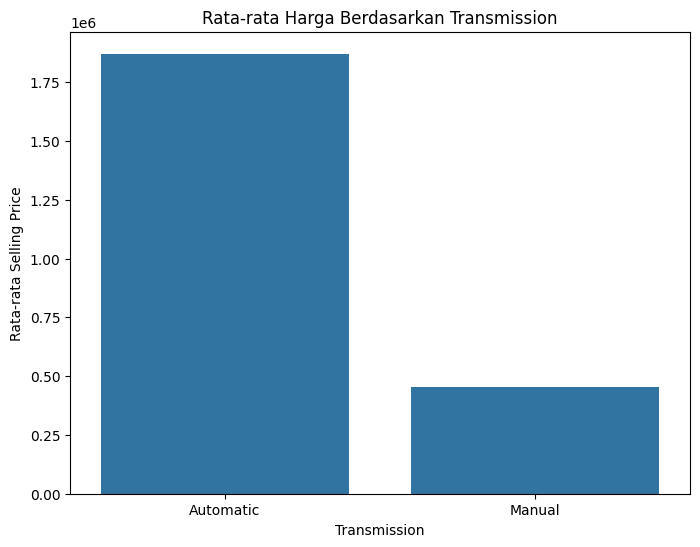

In [ ]:
avg_price_transmission = df.groupby('transmission')['selling_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=avg_price_transmission.index,
            y=avg_price_transmission.values)

plt.title('Rata-rata Harga Berdasarkan Transmission')
plt.xlabel('Transmission')
plt.ylabel('Rata-rata Selling Price')
plt.show()

# **Insight**

Mobil dengan transmisi Automatic memiliki rata-rata harga jual yang lebih tinggi dibandingkan Manual.
Hal ini menunjukkan bahwa tipe transmisi berpengaruh terhadap nilai pasar mobil bekas, kemungkinan karena faktor kenyamanan dan permintaan konsumen.

# **Composition**

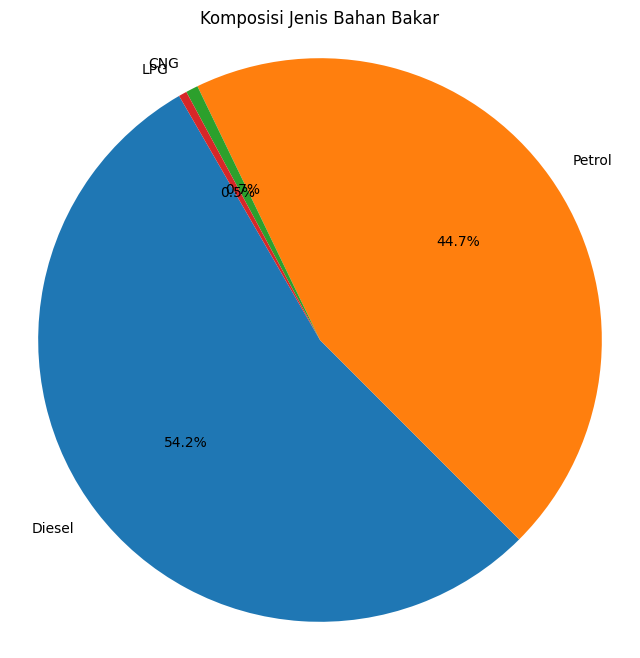

In [ ]:
fuel_count = df['fuel'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(fuel_count,
        labels=fuel_count.index,
        autopct='%1.1f%%',
        startangle=120)

plt.title('Komposisi Jenis Bahan Bakar')
plt.axis('equal')
plt.show()

# **Insight**

Sebagian besar mobil menggunakan Diesel dan Petrol, menunjukkan pasar mobil bekas didominasi bahan bakar konvensional.

# **Distribution**

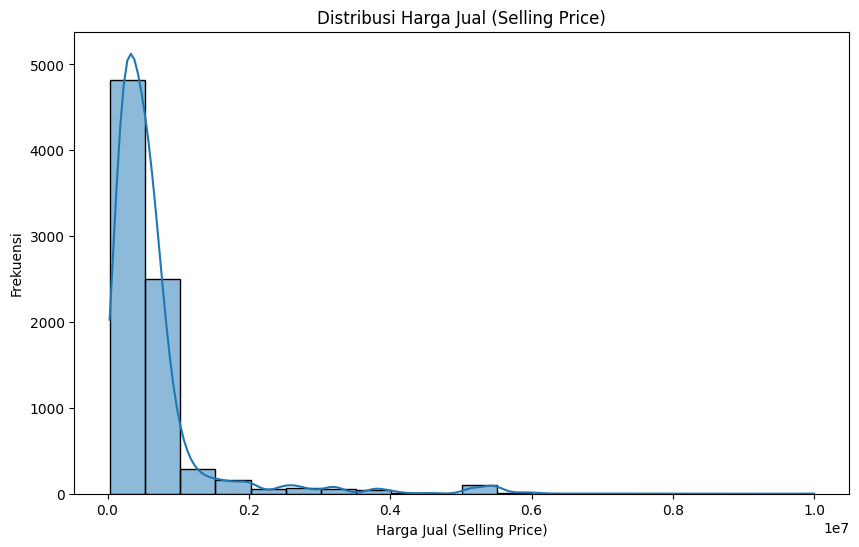

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=20, kde=True)
plt.title('Distribusi Harga Jual (Selling Price)')
plt.xlabel('Harga Jual (Selling Price)')
plt.ylabel('Frekuensi')
plt.show()

# **Insight**

Distribusi harga cenderung right-skewed, artinya mayoritas mobil berada di harga menengah ke bawah dengan sedikit mobil berharga sangat tinggi.

# **Relationship**

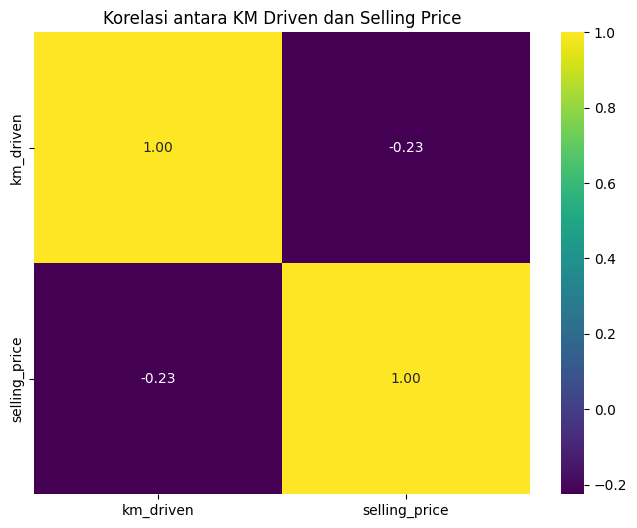

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['km_driven', 'selling_price']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara KM Driven dan Selling Price')
plt.show()

# **Insight**

Terlihat hubungan negatif: semakin tinggi kilometer mobil, semakin rendah harga jualnya.

# **Melihat Struktur Data(Informasi lanjutan)**


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


**Insight :**

1. Name

Jumlah baris: 8128
Tipe data: object
Deskripsi: Menyimpan nama lengkap mobil (mengandung brand dan model).

2. Year

Jumlah baris: 8128
Tipe data: int64
Deskripsi: Tahun produksi mobil. Berpengaruh terhadap harga karena faktor depresiasi.

3. Selling_Price

Jumlah baris: 8128
Tipe data: int64
Deskripsi: Harga jual mobil. Merupakan variabel target dalam prediksi.

4. KM_Driven

Jumlah baris: 8128
Tipe data: int64
Deskripsi: Total jarak tempuh mobil. Semakin tinggi biasanya harga semakin rendah.

5. Fuel

Jumlah baris: 8128
Tipe data: object
Deskripsi: Jenis bahan bakar mobil (Petrol, Diesel, CNG, dll).

6. Seller_Type

Jumlah baris: 8128
Tipe data: object
Deskripsi: Tipe penjual (Dealer, Individual, dll).

7. Transmission

Jumlah baris: 8128
Tipe data: object
Deskripsi: Jenis transmisi mobil (Manual / Automatic).

8. Owner

Jumlah baris: 8128
Tipe data: object
Deskripsi: Status kepemilikan mobil (First Owner, Second Owner, dll).

9. Mileage

Jumlah baris: 7907
Tipe data: object
Deskripsi: Efisiensi bahan bakar mobil. Masih bertipe object karena mengandung satuan (kmpl).

10. Engine

Jumlah baris: 7907
Tipe data: object
Deskripsi: Kapasitas mesin mobil. Perlu ekstraksi angka karena masih mengandung satuan (CC).

11. Max_Power

Jumlah baris: 7913
Tipe data: object
Deskripsi: Daya maksimum mesin mobil. Masih mengandung satuan (bhp) sehingga perlu konversi numerik.

12. Torque

Jumlah baris: 7906
Tipe data: object
Deskripsi: Torsi mesin mobil. Perlu preprocessing karena masih berupa teks.

13. Seats

Jumlah baris: 7907
Tipe data: float64
Deskripsi: Jumlah kursi mobil. Memiliki beberapa missing values.

# **Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


**Insight**

Statistik Deskriptif Kolom Selling_Price:

Count = 8128 menunjukkan terdapat 8128 data harga mobil yang dianalisis.

Mean = 638.271 menunjukkan rata-rata harga mobil berada pada kisaran menengah ke atas.

Median = 450.000 menunjukkan setengah data mobil memiliki harga di bawah 450 ribu.

Minimum = 29.999 menunjukkan harga mobil terendah dalam dataset.

Maximum = 10.000.000 menunjukkan adanya mobil dengan harga sangat tinggi (kategori premium/luxury).

Kesimpulan: Distribusi harga mobil tidak simetris karena terdapat beberapa mobil dengan harga sangat mahal yang meningkatkan nilai rata-rata (right-skewed).


**Statistik Deskriptif Kolom Year:**

Count = 8128 menunjukkan terdapat 8128 data tahun produksi mobil yang dianalisis.

Mean = 2013 menunjukkan rata-rata mobil diproduksi sekitar tahun 2013.

Median = 2015 menunjukkan sebagian besar mobil berada di tahun produksi yang lebih baru dari rata-rata.

Minimum = 1983 menunjukkan terdapat mobil yang cukup tua dalam dataset.

Maximum = 2020 menunjukkan mobil terbaru dalam dataset.

Kesimpulan: Dataset didominasi mobil produksi 2011–2017, sehingga usia mobil menjadi faktor penting dalam mempengaruhi harga.


**Statistik Deskriptif Kolom KM_Driven:**

Count = 8128 menunjukkan terdapat 8128 data jarak tempuh mobil yang dianalisis.

Mean = 69.819 km menunjukkan rata-rata mobil telah digunakan dalam jarak cukup tinggi.

Median = 60.000 km menunjukkan setengah mobil memiliki jarak tempuh di bawah angka tersebut.

Minimum = 1 km menunjukkan terdapat mobil dengan jarak tempuh sangat rendah.

Maximum = 2.360.457 km menunjukkan adanya nilai ekstrem (outlier).

Kesimpulan: Terdapat perbedaan jarak tempuh yang sangat besar antar mobil, dan kemungkinan terdapat outlier yang perlu ditangani sebelum modeling.


**Statistik Deskriptif Kolom Seats:**

Count = 7907 menunjukkan terdapat 7907 data jumlah kursi yang tersedia.

Mean = 5,41 menunjukkan rata-rata mobil memiliki 5 kursi.

Median = 5 menunjukkan mayoritas mobil adalah tipe 5-seater.

Minimum = 2 menunjukkan terdapat mobil sport atau city car kecil.

Maximum = 14 menunjukkan adanya mobil kategori van atau minibus.

Kesimpulan: Dataset didominasi mobil 5 kursi, namun terdapat variasi ukuran kendaraan yang cukup besar.

# **Cek Tipe Data Pada Setiap Kolom**

In [ ]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage,object
engine,object


# **Cek Inconsistent Values pada setiap kolom**

hal ini dilakukan untuk mengecek ke inconsistentan pada suatu kolom

In [ ]:
print(df['name'].unique())

['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' ... 'Tata Nexon 1.5 Revotorq XT'
 'Ford Freestyle Titanium Plus Diesel BSIV'
 'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV']


In [ ]:
print(df['year'].unique())

[2014 2006 2010 2007 2017 2001 2011 2013 2005 2009 2016 2012 2002 2015
 2018 2003 2019 2008 2020 1999 2000 1983 2004 1996 1994 1995 1998 1997
 1991]


In [ ]:
print(df['selling_price'].unique())

[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000    70000   730000   650000   330000
   366000  1149000   425000  2100000   925000   675000   819999   390000
  1500000   700000  1450000  1090000   850000  1650000  1750000  1590000
  1689999  1425000   265000   190000   630000   540000   448000   745000
  1025000   235000  1700000    50000  1200000   610000  2500000   484999
   315000   475000   290000   455000   351000   535000   175000   565000
   120000   725000   185000   615000   270000   625000   866000   375000
   522000   451999   780000   595000  1140000   360000   105000   135000
   690000  3975000  5150000  3200000  4100000  4500000  6000000  3790000
  2150000  5800000  1864999  2700000   795000  3400000  2650000  5850000
   975000   805000  2625000   811000   550000   645

**Insight**

**- pada kolom name:**

Hasil menunjukkan berbagai nama mobil seperti:
Maruti Swift Dzire VDI, Skoda Rapid 1.5 TDI Ambition, Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV, dll.

Tidak ditemukan perbedaan huruf besar/kecil yang mencurigakan.

Nama mobil cukup bervariasi (2058 model unik).

Tidak terlihat duplikasi karena perbedaan spasi atau format.

Kolom ini bersifat deskriptif dan bisa diekstrak menjadi brand mobil untuk feature engineering.

Kesimpulan: Tidak ditemukan inconsistent value yang signifikan pada kolom name.


**- pada kolom year:**

Nilai unik berkisar antara:
1983 hingga 2020.

Semua nilai berupa angka valid (tahun produksi).

Tidak ditemukan format aneh atau nilai string.

Tidak ada tahun yang tidak masuk akal (misalnya 2050 atau 0).

Kesimpulan: Tidak terdapat inconsistent value pada kolom year.

**- pada kolom selling_price:**

Nilai harga bervariasi dari:
30.000 hingga 10.000.000.

Semua nilai berbentuk numerik.

Tidak ditemukan format aneh atau karakter selain angka.

Terdapat variasi harga sangat besar → indikasi adanya outlier (mobil premium).

Nilai seperti 31.504 atau 93.150 menunjukkan harga realistis dan bukan error format.

Kesimpulan: Tidak terdapat inconsistent value pada kolom selling_price, namun terdapat kemungkinan outlier harga tinggi yang perlu dianalisis lebih lanjut.



# **Cek Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
name,0.000000
year,0.000000
selling_price,0.000000
km_driven,0.000000
fuel,0.000000
seller_type,0.000000
transmission,0.000000
owner,0.000000
mileage,2.718996
engine,2.718996


**insight**

- Sebagian besar kolom tidak memiliki missing value (0%), sehingga data utama seperti harga, tahun, dan km_driven sudah lengkap dan siap digunakan.

- Missing value hanya terdapat pada kolom spesifikasi mesin (mileage, engine, max_power, torque, seats) dengan persentase sekitar 2–3%.

- Persentase tersebut tergolong rendah (<5%), sehingga masih aman dan bisa ditangani dengan imputasi tanpa perlu menghapus banyak data.

# **Cek Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
291,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
296,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
370,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
371,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
372,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7987,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
7988,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
8117,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


**insight**

- Ada data yang benar-benar identik (contoh: Tata Indigo muncul 2x persis sama).

- Itu kemungkinan besar data entry error / scraping duplicate, bukan mobil berbeda.

- Kalau tidak dihapus, bisa:
1. Mengganggu distribusi data

2. Membuat model bias (harga jadi “terhitung dua kali”)

# **Cek Outliers**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

display(results_df)

Kolom,Persentase Outliers
year,0.996555
selling_price,7.381890
km_driven,2.091535
seats,20.337106


**insight**

dataset punya outlier terutama di seats (20.33%) dan selling_price (7.38%), sedangkan km_driven (2.09%) dan year (0.99%) relatif kecil. Outlier seats kemungkinan besar bukan error, tapi karena mayoritas mobil 5 seat sehingga 7–10 seat dianggap ekstrem oleh metode IQR. Outlier harga muncul karena perbedaan segmen (mobil biasa vs luxury), jadi ini efek distribusi yang lebar, bukan data salah. Sementara km_driven dan year masih dalam batas wajar.

# **Eksplorasi Data (EDA)**

**Comparison (Perbandingan)**

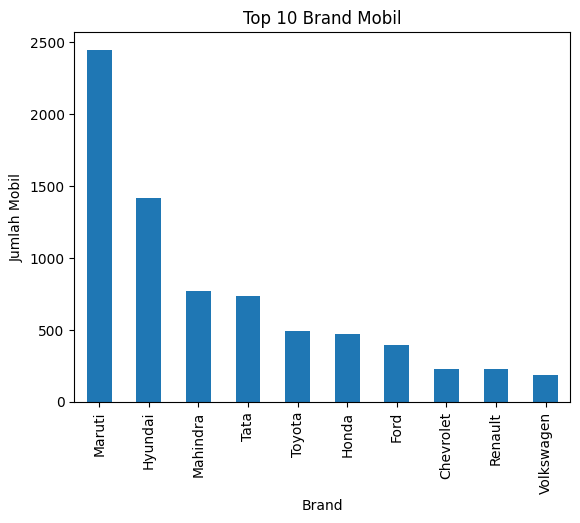

In [ ]:
df['brand'] = df['name'].str.split().str[0]

brand_count = df['brand'].value_counts().head(10)

brand_count.plot(kind='bar')
plt.title("Top 10 Brand Mobil")
plt.xlabel("Brand")
plt.ylabel("Jumlah Mobil")
plt.show()

**insight**

- Maruti mendominasi sangat jauh dibanding brand lain → menunjukkan pasar didominasi mobil entry-level & mass market.

- Hyundai berada di posisi kedua dengan selisih cukup besar dari Maruti.

- Mahindra dan Tata berada di posisi menengah → cukup kuat di segmen SUV & mobil lokal.

- Toyota dan Honda tetap konsisten tapi tidak mendominasi → kemungkinan karena harga lebih tinggi dibanding brand lokal.

- Chevrolet, Renault, Volkswagen memiliki jumlah listing jauh lebih sedikit → market share kecil atau sudah tidak terlalu aktif di pasar tersebut.

**Composition (Komposisi)**

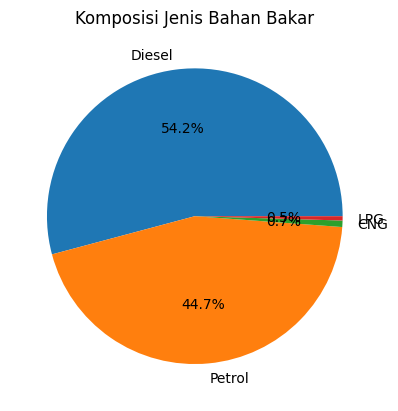

In [ ]:
fuel_count = df['fuel'].value_counts()

fuel_count.plot(kind='pie', autopct='%1.1f%%')
plt.title("Komposisi Jenis Bahan Bakar")
plt.ylabel("")
plt.show()

**insight**

- Diesel (54.2%) mendominasi dataset → lebih dari setengah mobil menggunakan diesel.

- Petrol (44.7%) hampir seimbang dengan diesel → pasar cukup kompetitif antara dua jenis ini.

- CNG & LPG (<1%) sangat kecil → hampir tidak signifikan dalam dataset.

# **Distribution (Distribusi)**

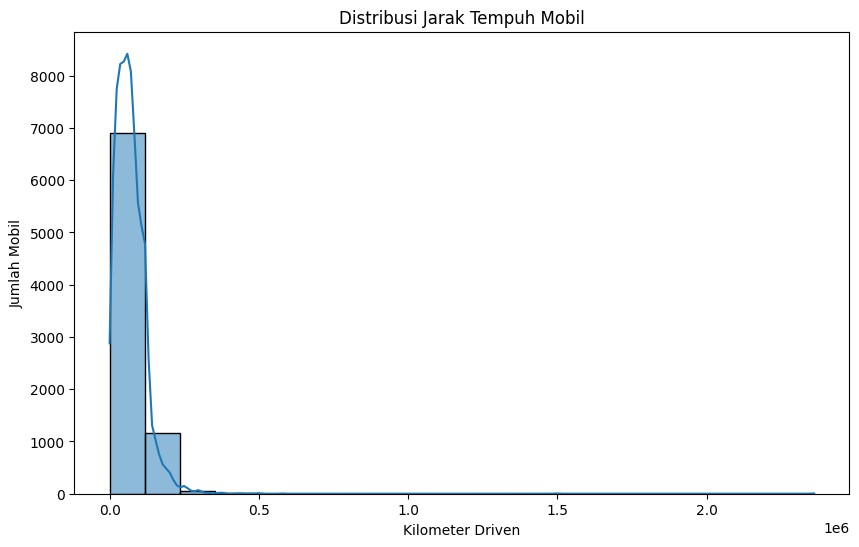

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['km_driven'], bins=20, kde=True)
plt.title('Distribusi Jarak Tempuh Mobil')
plt.xlabel('Kilometer Driven')
plt.ylabel('Jumlah Mobil')
plt.show()

# **Relationship (Hubungan)**

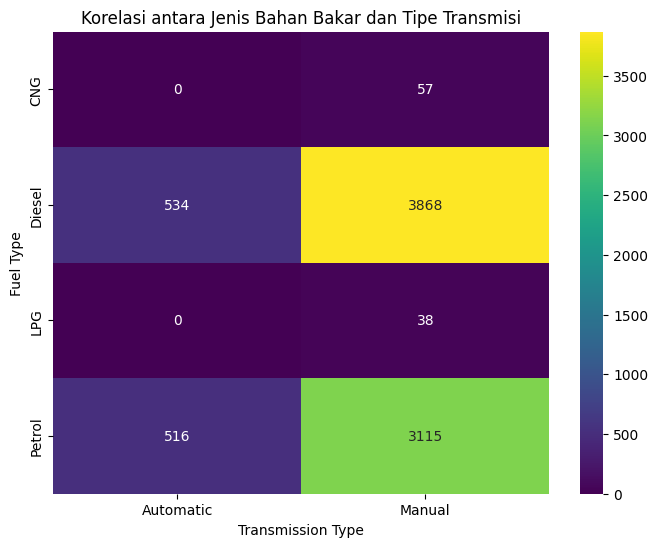

In [ ]:
contingency_table = pd.crosstab(df['fuel'], df['transmission'])

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data=contingency_table, annot=True, cmap='viridis', fmt='d')
plt.title('Korelasi antara Jenis Bahan Bakar dan Tipe Transmisi')
plt.xlabel('Transmission Type')
plt.ylabel('Fuel Type')
plt.show()

**insight**

1. Transmisi manual mendominasi untuk semua jenis bahan bakar.
2. Diesel–Manual adalah kombinasi terbanyak (paling dominan di data).
3. Petrol juga jauh lebih banyak manual dibanding automatic.
4. CNG dan LPG jumlahnya sangat sedikit, dan hampir semuanya manual.
5. Automatic relatif lebih sedikit di semua jenis bahan bakar, terutama CNG & LPG (hampir nol).

# **Menyimpan Dataset dalam xlsx**

In [ ]:
df.to_excel("Car Price Prediction.xlsx", index=False)

# **Data Preparation (Data Cleaning, Construct Data, Data Reduction)**

**1. Penanganan Tipe Data**

In [ ]:
# Mengubah kolom numerik ke numerik
df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')
df['km_driven'] = pd.to_numeric(df['km_driven'], errors='coerce')

# Mengubah kolom kategori menjadi object/string
cols_object = ['fuel','seller_type','transmission','owner']
for col in cols_object:
    df[col] = df[col].astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
 13  brand          8128 non-null   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 889.1+ KB


- Manual mendominasi, terutama untuk Petrol.

- Automatic jarang, terutama di Diesel.

- Petrol lebih populer dibanding Diesel.

- Heatmap menunjukkan frekuensi, bukan sebab-akibat, tapi bisa bantu lihat tren pilihan mobil.

**2. Penanganan Inconsistent Values**

Penyeragaman huruf dilakukan agar tidak terjadi perbedaan kategori akibat variasi penulisan seperti huruf besar dan kecil.

In [ ]:
# Standardisasi format teks untuk kolom kategori
df['fuel'] = df['fuel'].str.upper()
df['seller_type'] = df['seller_type'].str.title()
df['transmission'] = df['transmission'].str.title()
df['owner'] = df['owner'].str.title()

# Tampilkan unique values
for col in ['fuel','seller_type','transmission','owner']:
    print(f"Unique values for {col}: {df[col].unique()}")

Unique values for fuel: ['DIESEL' 'PETROL' 'LPG' 'CNG']
Unique values for seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']
Unique values for transmission: ['Manual' 'Automatic']
Unique values for owner: ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


- Fuel: Dataset sekarang lengkap, ada Diesel, Petrol, LPG, dan CNG → menunjukkan variasi bahan bakar yang tersedia.

- Seller Type: Terdapat Individual, Dealer, dan Trustmark Dealer → memungkinkan analisis harga berbeda berdasarkan jenis penjual.

- Transmission: Manual dan Automatic ada, tapi biasanya Manual lebih banyak.

- Owner: First, Second, Third, Fourth & Above, dan Test Drive Car → mayoritas mobil kemungkinan First Owner, tapi ada juga mobil bekas dengan beberapa pemilik sebelumnya, termasuk mobil test drive.

**3. penanganan missing values**

In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


- Analisis harga vs fuel/transmission/owner bisa dilakukan tanpa masalah.

- Untuk analisis engine, mileage, max_power, torque, seats, perlu imputasi atau hapus baris missing tergantung analisis.

- Data mayoritas lengkap, jadi dataset masih cukup representatif untuk model prediksi harga mobil.

Kolom penting untuk analisis harga dan kategori (selling_price, year, km_driven, fuel, transmission, owner, seller_type) → tidak perlu imputasi, karena sudah lengkap.

**4. Penanganan Duplicate Values**

untuk menangani/hapus data yang terduplikat

In [ ]:
print("\nJumlah data duplikat:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Jumlah data setelah hapus duplikat:")
print(df.shape)


Jumlah data duplikat:
1202
Jumlah data setelah hapus duplikat:
(6926, 14)


**Penanganan Outliers (price & size)**

In [ ]:
columns_to_impute = ['selling_price','km_driven']

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

df[['selling_price','km_driven']].describe()

,selling_price,km_driven
count,6.926000e+03,6926.000000
mean,4.704444e+05,72188.995668
std,2.943957e+05,43440.909202
min,2.999900e+04,1.000000
25%,2.500000e+05,40000.000000
50%,4.000000e+05,70000.000000
75%,6.335000e+05,100000.000000
max,1.208750e+06,190000.000000


Setelah IQR, harga (selling_price) dan jarak tempuh (km_driven) sudah dalam rentang wajar, outlier ekstrem dibatasi → distribusi data lebih stabil dan representatif.

**6. Construct Data (Membuat Kolom Baru)**

In [ ]:
# Kolom kategori harga
def kategori_harga(harga):
    if harga < 200000:
        return 'Murah'
    elif harga <= 500000:
        return 'Sedang'
    else:
        return 'Mahal'

df['kategori_harga'] = df['selling_price'].apply(kategori_harga)

# Kolom kategori jarak tempuh
def kategori_km(km):
    if km < 50000:
        return 'Rendah'
    elif km <= 150000:
        return 'Sedang'
    else:
        return 'Tinggi'

df['kategori_km'] = df['km_driven'].apply(kategori_km)

df[['selling_price','kategori_harga','km_driven','kategori_km']].head(10)

,selling_price,kategori_harga,km_driven,kategori_km
0,450000,Sedang,145500,Sedang
1,370000,Sedang,120000,Sedang
2,158000,Murah,140000,Sedang
3,225000,Sedang,127000,Sedang
4,130000,Murah,120000,Sedang
5,440000,Sedang,45000,Rendah
6,96000,Murah,175000,Tinggi
7,45000,Murah,5000,Rendah
8,350000,Sedang,90000,Sedang
9,200000,Sedang,169000,Tinggi


- Kategori Harga (kategori_harga):

Sebagian besar mobil masuk Sedang (200.000–500.000), beberapa Murah (<200.000) dan sedikit yang Mahal (>500.000).

Menunjukkan mayoritas mobil bekas berada di harga menengah.

- Kategori Jarak Tempuh (kategori_km):

Sebagian besar mobil memiliki km_driven Sedang (50.000–150.000 km), sebagian kecil Rendah (<50.000 km) dan beberapa Tinggi (>150.000 km).

Artinya, mobil mayoritas digunakan wajar, tidak terlalu jarang atau terlalu banyak dipakai.

**7. Data Reduction (Menghapus Kolom Tidak Relevan)**

Untuk di data saya tidak diperlukan data reduction, karena:


Jumlah baris: 8128 → tidak terlalu besar, masih nyaman untuk analisis maupun modeling.

Jumlah kolom: 13 → cukup sedikit, tidak banyak fitur yang redundan.

Missing values: hanya sedikit di mileage, engine, max_power, torque, seats → sebagian besar kolom lengkap.

Tipe data: numerik dan kategorikal seimbang, tidak ada kolom yang perlu dihapus karena duplikasi atau irrelevan.

# **Data setelah ditangani**

In [ ]:
df.info()
df.head()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            6926 non-null   object 
 1   year            6926 non-null   int64  
 2   selling_price   6926 non-null   int64  
 3   km_driven       6926 non-null   int64  
 4   fuel            6926 non-null   object 
 5   seller_type     6926 non-null   object 
 6   transmission    6926 non-null   object 
 7   owner           6926 non-null   object 
 8   mileage         6718 non-null   object 
 9   engine          6718 non-null   object 
 10  max_power       6721 non-null   object 
 11  torque          6717 non-null   object 
 12  seats           6718 non-null   float64
 13  brand           6926 non-null   object 
 14  kategori_harga  6926 non-null   object 
 15  kategori_km     6926 non-null   object 
dtypes: float64(1), int64(3), object(12)
memory usage: 919.9+ KB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,kategori_harga,kategori_km
count,6926,6926.000000,6.926000e+03,6926.000000,6926,6926,6926,6926,6718,6718,6721,6717,6718.000000,6926,6926,6926
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN,32,3,3
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,DIESEL,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN,Maruti,Sedang,Sedang
freq,118,NaN,NaN,NaN,3755,6218,6342,4242,210,907,324,472,NaN,2165,3106,4293
mean,NaN,2013.420300,4.704444e+05,72188.995668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.434653,NaN,NaN,NaN
std,NaN,4.078286,2.943957e+05,43440.909202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.984230,NaN,NaN,NaN
min,NaN,1983.000000,2.999900e+04,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
25%,NaN,2011.000000,2.500000e+05,40000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN
50%,NaN,2014.000000,4.000000e+05,70000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN
75%,NaN,2017.000000,6.335000e+05,100000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN


# **Menyimpan Dataset dalam bentuk csv**

In [ ]:
df.to_csv('/content/Car Price Prediction.xlsx', index=False)

# **Visualisasi Data**

## Bar Chart

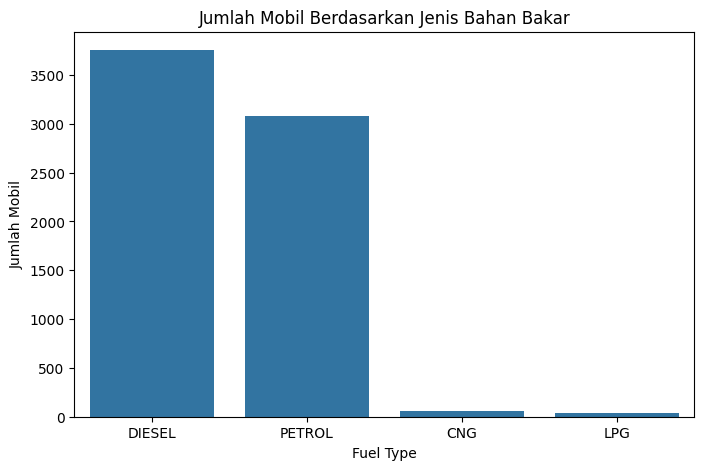

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fuel_counts = df['fuel'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values)

plt.title("Jumlah Mobil Berdasarkan Jenis Bahan Bakar")
plt.xlabel("Fuel Type")
plt.ylabel("Jumlah Mobil")

plt.show()

### **Insight**
Visualisasi menunjukkan distribusi jumlah mobil berdasarkan jenis bahan bakar. Dari grafik terlihat bahwa mobil dengan bahan bakar diesel dan petrol memiliki jumlah paling banyak dibandingkan jenis bahan bakar lainnya.

### **Tindakan**
Penjual mobil dapat lebih fokus menyediakan mobil dengan bahan bakar diesel dan petrol karena kedua jenis bahan bakar tersebut lebih banyak tersedia di pasar. Hal ini juga dapat menjadi indikator bahwa permintaan terhadap mobil dengan bahan bakar tersebut relatif tinggi.

## Pie Chart

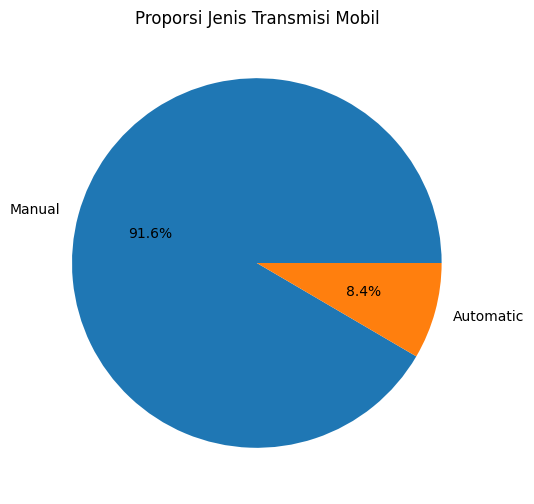

In [ ]:
trans_counts = df['transmission'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(trans_counts.values, labels=trans_counts.index, autopct='%1.1f%%')

plt.title("Proporsi Jenis Transmisi Mobil")

plt.show()

### **Insight**
Visualisasi Pie Chart menunjukkan proporsi jenis transmisi mobil yang terdapat pada dataset. Terlihat bahwa mobil dengan transmisi manual memiliki persentase lebih besar dibandingkan mobil dengan transmisi automatic.

### **Tindakan**
Penjual mobil dapat mempertimbangkan untuk menyediakan lebih banyak mobil dengan transmisi manual karena jumlahnya lebih dominan di pasar mobil bekas. Di sisi lain, mobil dengan transmisi automatic dapat menjadi pilihan bagi konsumen dengan preferensi kenyamanan berkendara.

## Line Chart

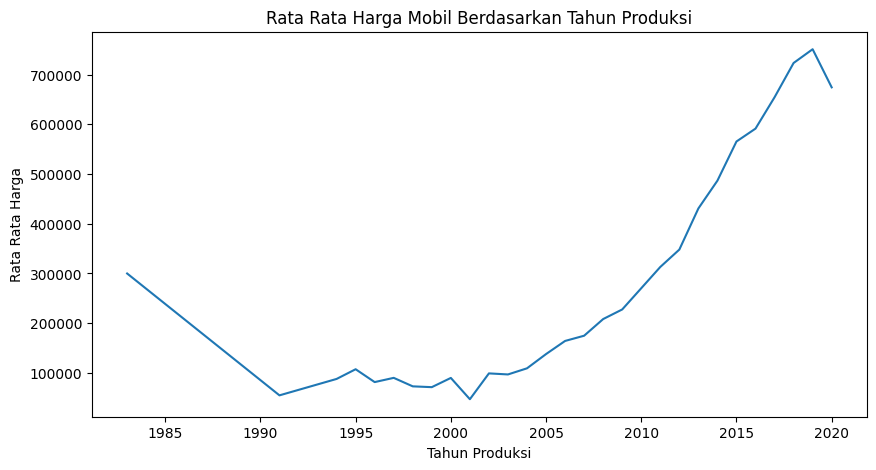

In [ ]:
avg_price_year = df.groupby("year")["selling_price"].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_price_year.index, avg_price_year.values)

plt.title("Rata Rata Harga Mobil Berdasarkan Tahun Produksi")
plt.xlabel("Tahun Produksi")
plt.ylabel("Rata Rata Harga")

plt.show()

### **Insight**
Visualisasi menunjukkan rata rata harga mobil berdasarkan tahun produksi. Terlihat bahwa mobil dengan tahun produksi lama memiliki harga yang jauh lebih rendah dibandingkan mobil dengan tahun produksi yang lebih baru. Mulai sekitar tahun 2005 harga rata rata mobil mengalami peningkatan yang cukup signifikan hingga mencapai puncak pada tahun sekitar 2019. Setelah itu terlihat sedikit penurunan pada tahun berikutnya.

### **Tindakan**
Penjual mobil dapat mempertimbangkan tahun produksi sebagai faktor utama dalam menentukan harga jual kendaraan. Mobil dengan tahun produksi yang lebih baru dapat dipasarkan dengan harga lebih tinggi karena memiliki nilai pasar yang lebih besar. Sementara itu pembeli dapat menggunakan informasi ini untuk membandingkan harga mobil berdasarkan usia kendaraan sebelum melakukan pembelian.

## Histogram

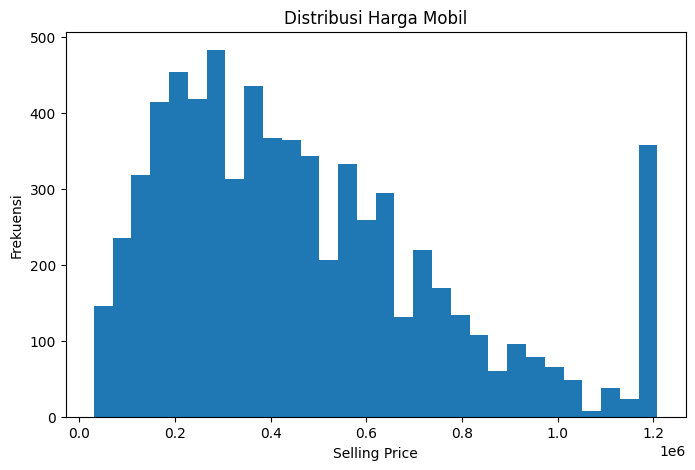

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["selling_price"], bins=30)

plt.title("Distribusi Harga Mobil")
plt.xlabel("Selling Price")
plt.ylabel("Frekuensi")

plt.show()

### **Insight**
Histogram menunjukkan distribusi harga mobil pada dataset. Terlihat bahwa sebagian besar mobil berada pada rentang harga yang lebih rendah hingga menengah. Jumlah mobil dengan harga sangat tinggi jauh lebih sedikit dibandingkan mobil dengan harga yang lebih terjangkau.


### **Tindakan**
Penjual mobil dapat menyesuaikan strategi penjualan dengan menyediakan lebih banyak mobil pada rentang harga yang paling banyak muncul dalam distribusi. Pembeli juga dapat menggunakan informasi ini untuk memahami kisaran harga mobil yang paling umum tersedia di pasar mobil bekas.

## Boxplot

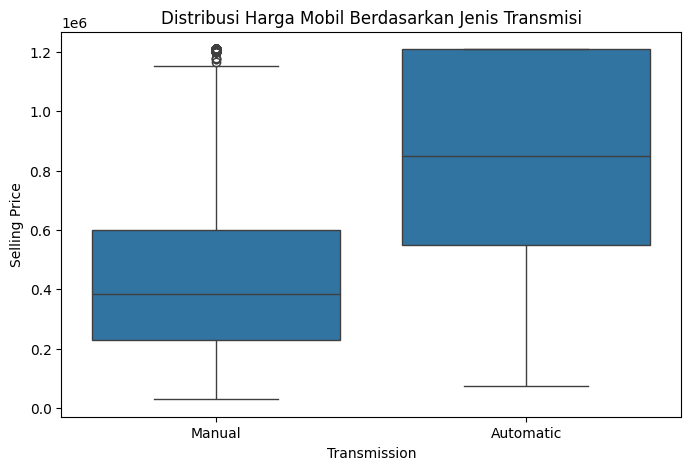

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="transmission", y="selling_price", data=df)

plt.title("Distribusi Harga Mobil Berdasarkan Jenis Transmisi")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

### **Insight**
Harga mobil dengan transmisi automatic cenderung lebih tinggi dibandingkan mobil manual. Hal ini terlihat dari median harga automatic yang berada di atas manual serta rentang harga yang lebih besar. Selain itu terdapat beberapa outlier pada mobil manual yang memiliki harga jauh lebih tinggi dibandingkan sebagian besar data.


### **Tindakan**
Penjual dapat memposisikan mobil automatic pada segmen harga yang lebih tinggi. Sementara itu mobil manual dapat menjadi pilihan bagi konsumen yang mencari kendaraan dengan harga lebih terjangkau.

## Scatterplot

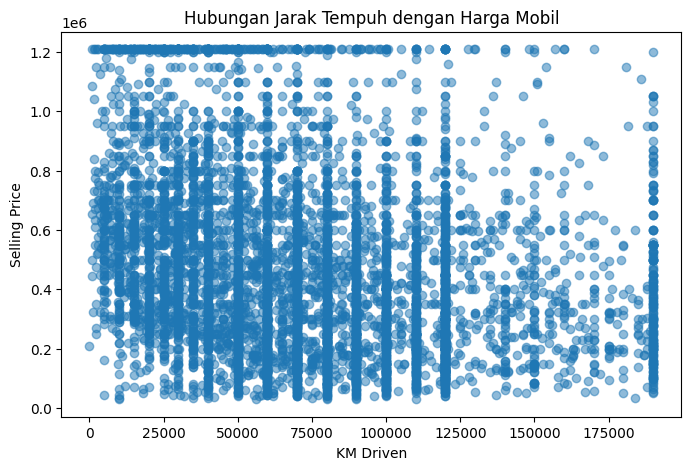

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.5)

plt.title("Hubungan Jarak Tempuh dengan Harga Mobil")
plt.xlabel("KM Driven")
plt.ylabel("Selling Price")

plt.show()

### **Insight**
Scatter Plot menunjukkan hubungan antara jarak tempuh mobil dan harga jual. Secara umum terlihat bahwa mobil dengan jarak tempuh yang lebih rendah cenderung memiliki harga lebih tinggi. Sebaliknya, mobil dengan jarak tempuh yang lebih besar banyak berada pada harga yang lebih rendah meskipun terdapat beberapa variasi harga pada setiap tingkat jarak tempuh.

### **Tindakan**
Penjual dapat mempertimbangkan jarak tempuh sebagai salah satu faktor dalam menentukan harga jual kendaraan. Pembeli juga dapat menggunakan informasi jarak tempuh untuk menilai nilai dan kondisi mobil sebelum melakukan pembelian.

## Heatmap

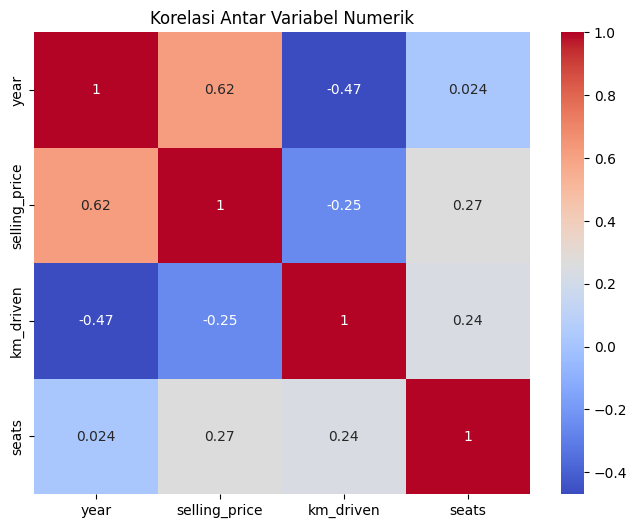

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Korelasi Antar Variabel Numerik")

plt.show()

### **Insight**
Heatmap menunjukkan bahwa year memiliki korelasi positif cukup kuat dengan selling_price sebesar 0.62, yang berarti mobil dengan tahun produksi lebih baru cenderung memiliki harga lebih tinggi. Sementara itu km_driven memiliki korelasi negatif terhadap selling_price sebesar -0.25, yang menunjukkan bahwa semakin tinggi jarak tempuh mobil maka harga jualnya cenderung menurun.

### **Tindakan**
Tahun produksi dan jarak tempuh dapat digunakan sebagai faktor utama dalam menentukan harga mobil. Informasi ini juga dapat dimanfaatkan dalam analisis lanjutan atau pengembangan model prediksi harga mobil.
